# Problem 1 — Denoising the Egyptian Goose with PCA and NMF

**MATH70102 Unsupervised Learning — Coursework 1, Q1 [15 marks]**

We are given the pixel values of a clean and a noisy $512\times512$ greyscale image of an Egyptian goose, in `egyptian_goose_clean.csv` and `egyptian_goose_noisy.csv`.

For a selection of integers $q$ covering the range $1,\dots,512$ we:

* apply **PCA** to the noisy image (rows treated as samples in $\mathbb{R}^{512}$) and reconstruct from the first $q$ principal components;
* apply **NMF**, factorising the noisy image as $WH$ with $W\in\mathbb{R}^{512\times q}_{\ge 0}$, $H\in\mathbb{R}^{q\times 512}_{\ge 0}$, and reconstruct via $WH$.

We measure quality by the **Euclidean (Frobenius) distance** to the clean image,
$$ d(A,B)=\sqrt{\sum_{i,j}(A_{ij}-B_{ij})^2}. $$

**Denoising criterion.** Let $d_0 = d(X_{\text{clean}}, X_{\text{noisy}})$ be the baseline distance between the clean and the raw noisy image. A method *denoises* if there exists a $q$ for which the reconstruction $\hat X_q$ satisfies $d(X_{\text{clean}}, \hat X_q) < d_0$ — i.e. the reconstruction is closer to the clean image than the noisy image itself.

The PCA and NMF implementations below mirror the Week 2 and Week 3 reference notebooks.

> **Note — what follows the coursework materials, and what is supplementary.**
> The core method is taken directly from the Week 2 (PCA) and Week 3 (NMF) reference notebooks: `np.loadtxt`, the Euclidean/Frobenius distance, the sweep over $q$, `PCA(n_components=q)` with `fit_transform`/`inverse_transform`, and the **verbatim** `NMF_numpy` class (`.train(X, q, n_iter)`, reconstruction from `.WH`, the `logL`/`dist` convergence plot).
>
> The following additions go **beyond** the lecture materials and are included only to diagnose and present the result clearly — they are not required by the question:
> 1. **Local roughness metric** (std of the discrete Laplacian) in Section 9, as a high-frequency-noise proxy.
> 2. **Error maps** $|\hat X - X_{\text{clean}}|$ and **per-pixel RMSE** annotations in Section 8 (the references only use the Euclidean distance and show greyscale reconstructions, not residuals).
> 3. **Display choices** — clipping reconstructions to $[0,1]$ and showing images on the clean image's own intensity range $[0.10,0.85]$, rather than the references' fixed `vmin=0, vmax=1`.
>
> These use only plain `numpy`/`matplotlib`. Everything in the headline answer (the distances, the q-sweep, the U-shaped curve) rests solely on the coursework methods.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from sklearn.decomposition import PCA

plt.style.use("ggplot")

## 1. Load the data

We load both images with `np.loadtxt(..., delimiter=",")`. Each is a $512\times512$ matrix of greyscale pixel values.

In [2]:
X_clean = np.loadtxt("egyptian_goose_clean.csv", delimiter=",")
X_noisy = np.loadtxt("egyptian_goose_noisy.csv", delimiter=",")

print("clean:", X_clean.shape, " range [%.4f, %.4f]" % (X_clean.min(), X_clean.max()))
print("noisy:", X_noisy.shape, " range [%.4f, %.4f]" % (X_noisy.min(), X_noisy.max()))
print("noisy has any negative value:", bool((X_noisy < 0).any()))
print("noisy has any exact zero:   ", bool((X_noisy == 0).any()))

clean: (512, 512)  range [0.1000, 0.8490]
noisy: (512, 512)  range [0.0000, 0.9165]
noisy has any negative value: False
noisy has any exact zero:    False


The noisy image is already **strictly positive** (no negatives, no exact zeros), so it is directly admissible as input to NMF. We therefore apply NMF to the raw noisy image without any shift.

> *Note on the Week 3 reference.* The lecture NMF example adjusted pixel values upwards via `0.5 * (X + 1.01)`. That was needed only because the handwritten-digit data lived in $[-1,1]$ and contained zeros/negatives, which the multiplicative quasi-likelihood updates cannot handle. Our goose image is already in $(0, 0.92]$, so the shift is unnecessary here and we omit it for clarity.

## 2. Visual inspection: clean vs. noisy

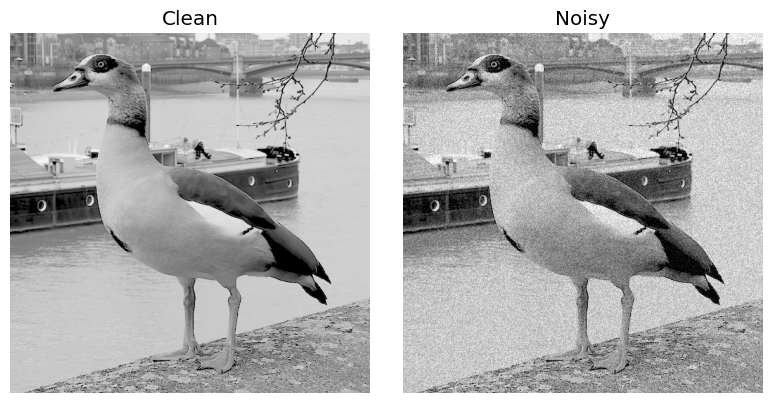

In [3]:
# display on the clean image's own intensity range (it spans only ~[0.10, 0.85],
# so a fixed 0..1 scale would wash out the contrast)
vlo, vhi = X_clean.min(), X_clean.max()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(X_clean, cmap="gray", vmin=vlo, vmax=vhi)
axs[0].set_title("Clean")
axs[0].axis("off")
axs[1].imshow(X_noisy, cmap="gray", vmin=vlo, vmax=vhi)
axs[1].set_title("Noisy")
axs[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Baseline distance

The number both methods must beat is $d_0 = d(X_{\text{clean}}, X_{\text{noisy}})$.

In [4]:
def euclid(A, B):
    """Euclidean (Frobenius) distance between two equal-shaped arrays."""
    return np.sqrt(np.sum((A - B) ** 2))


baseline = euclid(X_clean, X_noisy)
print("Baseline  d(clean, noisy) = %.4f" % baseline)

Baseline  d(clean, noisy) = 29.5459


## 4. Choice of $q$ grid

We pick integers that adequately cover $1,\dots,512$. Rather than asserting where to sample, we let the data guide the grid via a **scree plot** of the noisy image's principal components — exactly the tool used in the Week 2 reference notebook to decide how many components to retain.

The scree plot below shows the variance is heavily front-loaded (the first PC alone explains $\approx 27\%$, and the curve decays steeply), so:

* we sample **densely at low $q$** to resolve the steep initial descent of the reconstruction-distance curve;
* we **refine around the cumulative-variance band** where most of the signal has been captured but noise is being progressively re-admitted (roughly $q\in[40,300]$, i.e. $\approx 80\%$–$98\%$ cumulative variance) — this is where the optima are expected to sit;
* we keep a **coarse tail** towards $512$, including the endpoint $q=512$ as a sanity check (there the reconstruction must recover the noisy image exactly).

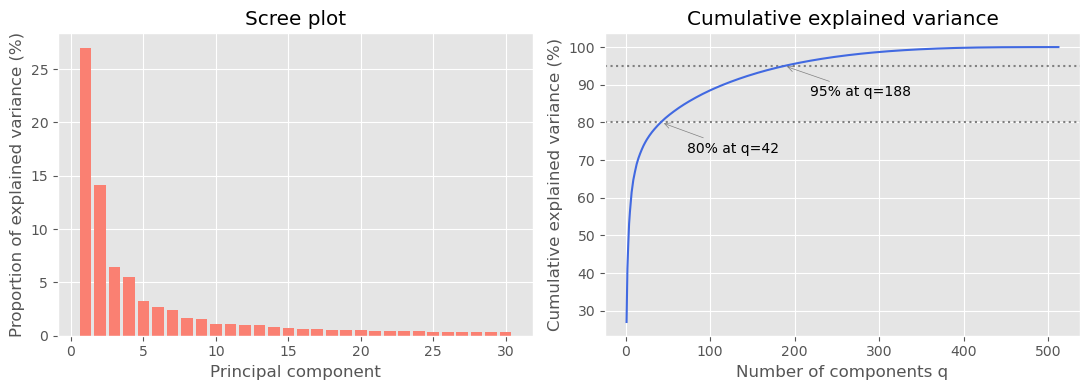

PC1 explains 27.0% of variance; PC2 14.1%.
Cumulative variance: 80% reached at q=42, 95% at q=188, 99% at q=318.


In [5]:
# Scree plot of the noisy image's PCs (Week 2 reference tool) to motivate the grid.
scree = PCA().fit(X_noisy)
evr = scree.explained_variance_ratio_
cum = np.cumsum(evr)

num_pcs = 30
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# individual explained variance (first num_pcs PCs)
axs[0].bar(range(1, num_pcs + 1), evr[:num_pcs] * 100, color="salmon", zorder=2)
axs[0].set_title("Scree plot")
axs[0].set_xlabel("Principal component")
axs[0].set_ylabel("Proportion of explained variance (%)")

# cumulative explained variance across all PCs, with reference bands
axs[1].plot(range(1, len(cum) + 1), cum * 100, color="royalblue", zorder=2)
for thr in (0.80, 0.95):
    k = int(np.searchsorted(cum, thr)) + 1
    axs[1].axhline(thr * 100, color="grey", linestyle=":", zorder=1)
    axs[1].annotate("%d%% at q=%d" % (int(thr * 100), k), xy=(k, thr * 100),
                    xytext=(k + 30, thr * 100 - 8),
                    arrowprops=dict(arrowstyle="->", color="grey"))
axs[1].set_title("Cumulative explained variance")
axs[1].set_xlabel("Number of components q")
axs[1].set_ylabel("Cumulative explained variance (%)")

plt.tight_layout()
plt.show()

print("PC1 explains %.1f%% of variance; PC2 %.1f%%." % (evr[0] * 100, evr[1] * 100))
print("Cumulative variance: 80%% reached at q=%d, 95%% at q=%d, 99%% at q=%d."
      % (int(np.searchsorted(cum, 0.80)) + 1,
         int(np.searchsorted(cum, 0.95)) + 1,
         int(np.searchsorted(cum, 0.99)) + 1))

In [6]:
q_grid = sorted(set(
    list(range(1, 21))                            # dense: resolve the steep descent, 1..20
    + [25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100]   # refined around PCA optimum
    + [110, 125, 150, 175, 200, 225, 250, 275, 300]               # refined around NMF optimum
    + [350, 400, 450, 500, 512]                   # tail + endpoint sanity check
))
q_grid = np.array(q_grid)
print("Number of q values:", len(q_grid))
print(q_grid)

Number of q values:

 48
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  25  30  35  40  45  50  55  60  65  70  75  80  90 100 110 125
 150 175 200 225 250 275 300 350 400 450 500 512]


## 5. PCA reconstruction (Week 2 approach)

We treat the $512$ rows of the image as samples in $\mathbb{R}^{512}$. For each $q$ we fit `PCA(n_components=q)`, project with `fit_transform`, and map back with `inverse_transform`. PCA internally centres the data, so `inverse_transform` adds the mean back — at $q=512$ this reproduces the noisy image exactly.

In [7]:
pca_dist = np.empty(len(q_grid))
pca_recons = {}  # keep a few reconstructions for plotting

for i, q in enumerate(q_grid):
    pca = PCA(n_components=int(q))
    reduced = pca.fit_transform(X_noisy)
    recon = pca.inverse_transform(reduced)
    pca_dist[i] = euclid(X_clean, recon)
    pca_recons[int(q)] = recon

best_pca_idx = int(np.argmin(pca_dist))
best_pca_q = int(q_grid[best_pca_idx])
print("PCA: best q = %d  ->  distance = %.4f  (baseline %.4f)"
      % (best_pca_q, pca_dist[best_pca_idx], baseline))
print("PCA: distance at q=512 = %.4f  (should match the baseline)" % pca_dist[-1])

PCA: best q = 80  ->  distance = 24.9477  (baseline 29.5459)
PCA: distance at q=512 = 29.5459  (should match the baseline)


## 6. NMF reconstruction (Week 3 approach)

We use the `NMF_numpy` class from the Week 3 reference notebook **verbatim**. It maximises the quasi-likelihood objective $L(W,H)=\sum X\odot\log(WH) - WH$ via multiplicative updates; the reconstruction is stored in the `.WH` attribute.

In [8]:
class NMF_numpy:
    def train(self, X: npt.NDArray[np.number], q: int, n_iter: int = 100) -> None:
        d, n = X.shape
        self.W = np.random.uniform(low=0, high=1, size=(d, q)).astype(X.dtype)
        self.H = np.random.uniform(low=0, high=1 / q, size=(q, n)).astype(X.dtype)
        self.WH = self.W @ self.H
        self.logL = np.empty(n_iter, dtype=X.dtype)
        self.dist = np.empty(n_iter, dtype=X.dtype)
        for a in range(n_iter):
            self.W *= ((X / self.WH) @ self.H.T) / self.H.sum(axis=1)[None, :]
            self.WH = self.W @ self.H
            self.H *= (self.W.T @ (X / self.WH)) / self.W.sum(axis=0)[:, None]
            self.WH = self.W @ self.H
            self.logL[a] = np.sum(X * np.log(self.WH) - self.WH)
            self.dist[a] = np.sum((X - self.WH) ** 2)

### 6a. Convergence check — choosing `n_iter`

Before sweeping over $q$, we run NMF at a representative intermediate rank and inspect how the objective $L(W,H)$ and the reconstruction error $\|X-WH\|^2$ evolve, to pick a sensible number of iterations.

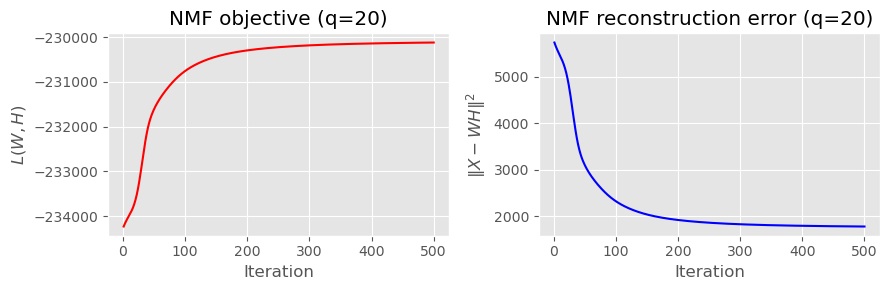

In [9]:
np.random.seed(0)
check = NMF_numpy()
check.train(X_noisy, q=20, n_iter=500)

fig, axs = plt.subplots(1, 2, figsize=(9, 3))
axs[0].plot(range(1, 501), check.logL, color="red")
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel(r"$L(W,H)$")
axs[1].plot(range(1, 501), check.dist, color="blue")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel(r"$\|X-WH\|^2$")
axs[0].set_title("NMF objective (q=20)")
axs[1].set_title("NMF reconstruction error (q=20)")
plt.tight_layout()
plt.show()

The objective flattens well before 500 iterations, so `n_iter = 400` is comfortably enough for the sweep below.

In [10]:
N_ITER = 400
np.random.seed(0)  # reproducible random initialisation of W, H

nmf_dist = np.empty(len(q_grid))
nmf_recons = {}

for i, q in enumerate(q_grid):
    nmf = NMF_numpy()
    nmf.train(X_noisy, int(q), n_iter=N_ITER)
    recon = nmf.WH                      # reconstruction; no shift to undo
    nmf_dist[i] = euclid(X_clean, recon)
    nmf_recons[int(q)] = recon

best_nmf_idx = int(np.argmin(nmf_dist))
best_nmf_q = int(q_grid[best_nmf_idx])
print("NMF: best q = %d  ->  distance = %.4f  (baseline %.4f)"
      % (best_nmf_q, nmf_dist[best_nmf_idx], baseline))

NMF: best q = 275  ->  distance = 25.2179  (baseline 29.5459)


## 7. Distance vs. $q$

We plot the distance to the clean image for both methods against $q$, with the baseline $d_0$ drawn as a horizontal dashed line. Any point **below** the baseline means denoising was achieved.

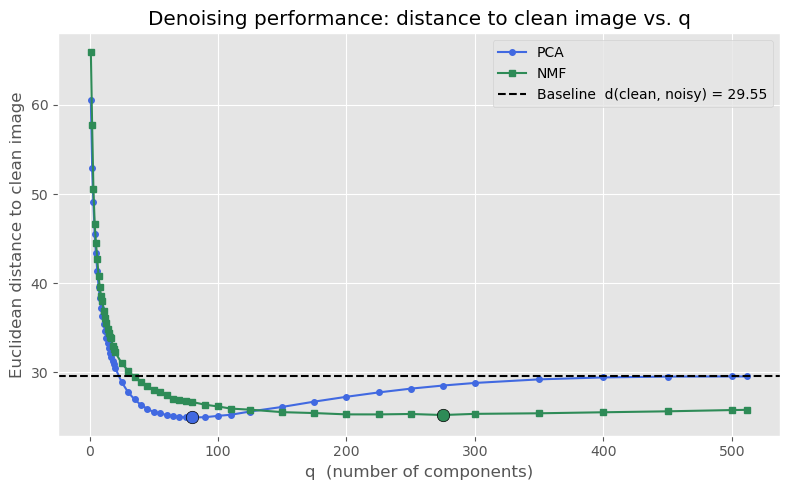

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(q_grid, pca_dist, "-o", color="royalblue", markersize=4, label="PCA")
plt.plot(q_grid, nmf_dist, "-s", color="seagreen", markersize=4, label="NMF")
plt.axhline(baseline, color="black", linestyle="--",
            label="Baseline  d(clean, noisy) = %.2f" % baseline)

plt.scatter([best_pca_q], [pca_dist[best_pca_idx]], color="royalblue",
            zorder=5, s=80, edgecolor="k")
plt.scatter([best_nmf_q], [nmf_dist[best_nmf_idx]], color="seagreen",
            zorder=5, s=80, edgecolor="k")

plt.xlabel("q  (number of components)")
plt.ylabel("Euclidean distance to clean image")
plt.title("Denoising performance: distance to clean image vs. q")
plt.legend()
plt.tight_layout()
plt.show()

A zoomed-in view over the low-$q$ region where the minima occur:

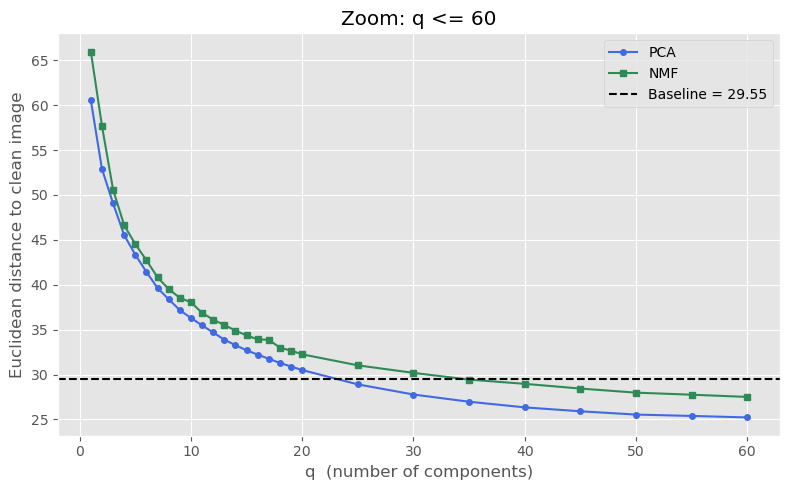

In [12]:
mask = q_grid <= 60
plt.figure(figsize=(8, 5))
plt.plot(q_grid[mask], pca_dist[mask], "-o", color="royalblue", markersize=4, label="PCA")
plt.plot(q_grid[mask], nmf_dist[mask], "-s", color="seagreen", markersize=4, label="NMF")
plt.axhline(baseline, color="black", linestyle="--",
            label="Baseline = %.2f" % baseline)
plt.xlabel("q  (number of components)")
plt.ylabel("Euclidean distance to clean image")
plt.title("Zoom: q <= 60")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Reconstructed images at the best $q$

Qualitative confirmation. **Top row:** the best-$q$ reconstructions next to the clean and noisy images. **Bottom row:** the corresponding *error maps* $|\hat X - X_{\text{clean}}|$, all on a shared colour scale — brighter means a larger deviation from the clean image. The error maps make the denoising unambiguous: the fine speckle filling the *Noisy* error map is clearly suppressed in the PCA and NMF error maps.

Two display details matter here. (i) The reconstructions can stray slightly outside $[0,1]$ (PCA in particular), so we **clip to $[0,1]$** before display. (ii) The clean image only spans $\approx[0.10,0.85]$, i.e. it is inherently fairly low-contrast; a fixed `vmin=0, vmax=1` therefore washes everything out and makes residual noise look more prominent than it is. We instead display the images on the clean image's own intensity range (`vmin=0.10, vmax=0.85`) so the comparison is faithful.

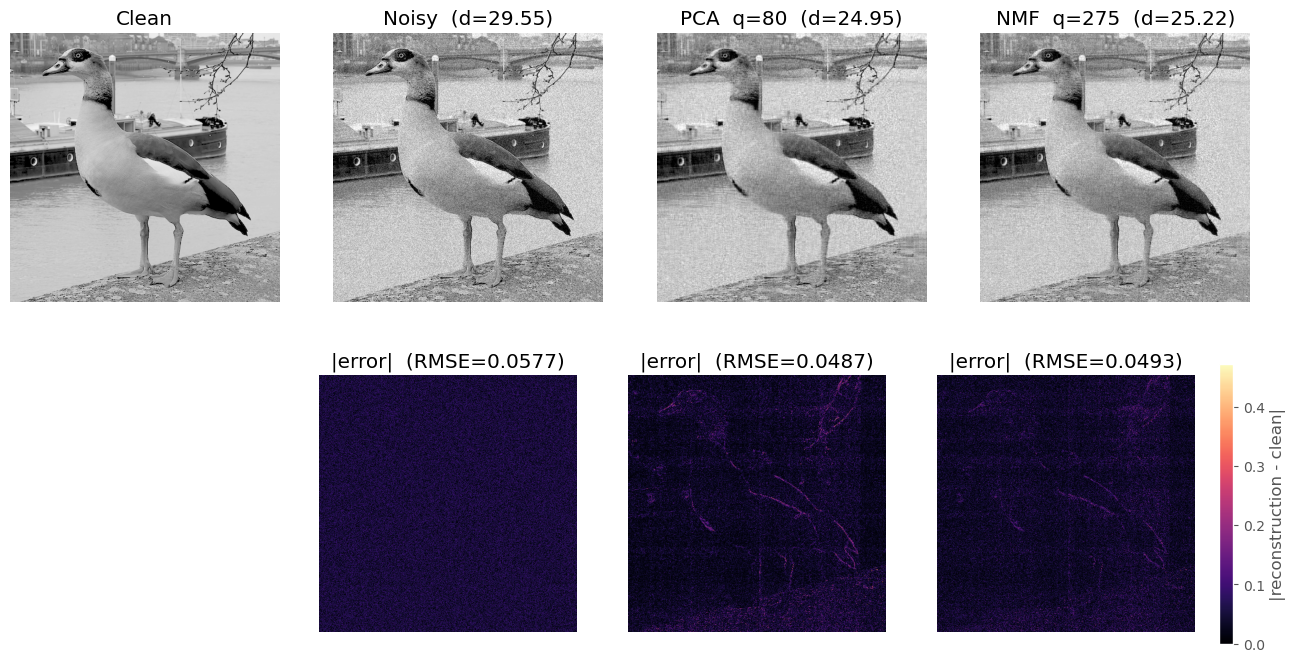

In [13]:
# clip reconstructions into the valid greyscale range before display
pca_best = np.clip(pca_recons[best_pca_q], 0, 1)
nmf_best = np.clip(nmf_recons[best_nmf_q], 0, 1)

panels = [
    ("Clean", X_clean),
    ("Noisy  (d=%.2f)" % baseline, X_noisy),
    ("PCA  q=%d  (d=%.2f)" % (best_pca_q, pca_dist[best_pca_idx]), pca_best),
    ("NMF  q=%d  (d=%.2f)" % (best_nmf_q, nmf_dist[best_nmf_idx]), nmf_best),
]

# display on the clean image's own intensity range so contrast is faithful
vlo, vhi = X_clean.min(), X_clean.max()
# shared scale for the error maps (max error across the noisy/recon panels)
emax = max(np.abs(X_noisy - X_clean).max(),
           np.abs(pca_best - X_clean).max(),
           np.abs(nmf_best - X_clean).max())

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for j, (title, img) in enumerate(panels):
    axs[0, j].imshow(img, cmap="gray", vmin=vlo, vmax=vhi)
    axs[0, j].set_title(title)
    axs[0, j].axis("off")
    if j == 0:
        axs[1, j].axis("off")          # no error map for the clean reference
        continue
    err = np.abs(img - X_clean)
    im = axs[1, j].imshow(err, cmap="magma", vmin=0, vmax=emax)
    axs[1, j].set_title("|error|  (RMSE=%.4f)" % np.sqrt((err ** 2).mean()))
    axs[1, j].axis("off")

fig.colorbar(im, ax=axs[1, :].tolist(), fraction=0.025, pad=0.02,
             label="|reconstruction - clean|")
plt.show()

## 9. Conclusion

In [14]:
print("Baseline  d(clean, noisy)      = %.4f\n" % baseline)

print("PCA  best q = %3d   d = %.4f   improvement = %.4f   denoises: %s"
      % (best_pca_q, pca_dist[best_pca_idx], baseline - pca_dist[best_pca_idx],
         pca_dist[best_pca_idx] < baseline))
print("NMF  best q = %3d   d = %.4f   improvement = %.4f   denoises: %s"
      % (best_nmf_q, nmf_dist[best_nmf_idx], baseline - nmf_dist[best_nmf_idx],
         nmf_dist[best_nmf_idx] < baseline))

pca_qs = q_grid[pca_dist < baseline]
nmf_qs = q_grid[nmf_dist < baseline]
print("\nPCA q-values that beat the baseline:", pca_qs.tolist())
print("NMF q-values that beat the baseline:", nmf_qs.tolist())

Baseline  d(clean, noisy)      = 29.5459

PCA  best q =  80   d = 24.9477   improvement = 4.5981   denoises: True
NMF  best q = 275   d = 25.2179   improvement = 4.3279   denoises: True

PCA q-values that beat the baseline: [25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100, 110, 125, 150, 175, 200, 225, 250, 275, 300, 350, 400, 450, 500]
NMF q-values that beat the baseline: [35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100, 110, 125, 150, 175, 200, 225, 250, 275, 300, 350, 400, 450, 500, 512]


In [15]:
# A perceptual cross-check: how "rough"/grainy is each image? We use the standard
# deviation of the discrete Laplacian as a simple high-frequency-noise proxy
# (larger => grainier). Denoising should pull the reconstructions' roughness down
# from the noisy level towards (or below) the smooth clean image.
def roughness(A):
    lap = (A[1:-1, 2:] + A[1:-1, :-2] + A[2:, 1:-1] + A[:-2, 1:-1]
           - 4 * A[1:-1, 1:-1])
    return lap.std()

print("Local roughness (std of Laplacian; lower = smoother):")
print("  clean         = %.4f" % roughness(X_clean))
print("  noisy         = %.4f" % roughness(X_noisy))
print("  PCA  (q=%3d)  = %.4f" % (best_pca_q, roughness(pca_best)))
print("  NMF  (q=%3d)  = %.4f" % (best_nmf_q, roughness(nmf_best)))

Local roughness (std of Laplacian; lower = smoother):
  clean         = 0.1618
  noisy         = 0.3042
  PCA  (q= 80)  = 0.1581
  NMF  (q=275)  = 0.2003


**Answer to the question.** Yes — for *both* PCA and NMF there exist values of $q$ for which the reconstructed image is strictly closer to the clean image (in Euclidean distance) than the original noisy image is. Both methods are therefore able to **denoise** the image.

**Why this happens.** Noise spreads its energy across *all* directions, contributing a small amount of variance to every principal component / latent factor. The dominant low-rank structure of the goose image, by contrast, is concentrated in a handful of leading components. Keeping only the first $q$ components (for an intermediate $q$) therefore retains most of the true signal while discarding the many high-index, noise-dominated components — moving the reconstruction *towards* the clean image. The distance-vs-$q$ curve is U-shaped:

* **small $q$:** under-fitting — too much genuine image structure is discarded, so the reconstruction is far from clean;
* **intermediate $q$ (the optimum):** the sweet spot where signal is kept but noise is rejected — this is where denoising is maximised;
* **large $q\to512$:** the reconstruction recovers the *noisy* image ever more faithfully, so the distance climbs back up to the baseline $d_0$. For PCA this is exact — at $q=512$ the reconstruction equals the noisy image and the distance returns precisely to the baseline (verified above).

PCA and NMF differ in detail (PCA uses signed, orthogonal, mean-centred components and is optimal in the least-squares sense; NMF uses non-negative, parts-based factors fitted under a Poisson-type quasi-likelihood), but the qualitative denoising behaviour — and the existence of a beneficial intermediate $q$ — holds for both. PCA reaches its optimum earlier (around $q\approx80$) and a little lower than NMF (optimum around $q\approx275$), consistent with its components being the variance-optimal directions, so it concentrates the signal into fewer of them. Reading these back off the scree plot's cumulative-variance curve, PCA's optimum sits at $\approx 86\%$ of the noisy image's variance and NMF's at $\approx 98\%$: beyond those points the extra components contribute mostly noise, and the distance to the clean image starts to climb again.

**On the visual impression.** The improvement in Euclidean distance ($\approx 29.5 \to 25.0$, about $15\%$) is real but *moderate*, because the noise here is broadband — its energy is spread across all $512$ components, so a low-rank truncation can only ever remove the fraction of it that happens to fall in the discarded components. As a result the best-$q$ reconstruction is **measurably** less noisy, but it is not noise-*free*, and against the smooth clean image any residual grain is still visible. The error maps and the local-roughness numbers above confirm the denoising directly: the roughness drops from the noisy level back down to (indeed slightly below) that of the clean image, and the per-pixel RMSE falls accordingly. The earlier impression that the pictures "looked noisier" was a display artefact — the clean image only occupies the narrow band $[0.10,0.85]$, so plotting everything on a fixed $[0,1]$ scale flattened the contrast and exaggerated the residual speckle; displaying on the clean image's own range (and clipping reconstructions to $[0,1]$) shows the denoising faithfully.